In [1]:
from cubespecfit.fitting import fitcube
from cubespecfit.models import ha_nii_model
from cubespecfit.params import build_params

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from astropy.io import fits

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


# Read in the data cube, uncertainty cube, FITS header
This example requires that the data be contained in extension 1, with the uncertainties in extension 2. The file used here is the level 3 pipeline product
for SPT2147-50, and is included in this repository.

In [2]:
file = "jw01355-o019_t005_nirspec_g395m-f290lp_s3d.fits"
hdul = fits.open(file)

cube = hdul[1].data
err_cube = hdul[2].data
header = hdul[1].header

# Determine the wavelength axis from the FITS header, set the systemic redshift
The redshift is used in determining which region of the cube contains the relevant emission lines. It does not have to be overly precise.

In [3]:
wl = np.linspace(header["CRVAL3"], header["CRVAL3"]+(header["NAXIS3"]-1)*header["CDELT3"], header["NAXIS3"])
z_sys = 3.760

# Set the model and define the parameter settings
This example uses the H-alpha+[NII] triple-Gaussian model, whose parameters are redshift, H-alpha integrated flux,
line sigma, the [NII]/H-alpha ratio and the continuum level.

`build_params` lets the velocity-like quantities be given in **km/s** rather than microns. Converting them by hand is
how bounds end up miscalibrated: an expression like `300/2.35/3e05*((1+z_sys)*0.65646)` cannot be checked by eye, and a
bound that is too tight does not raise — it silently pins the parameter and the map still looks plausible.

Two choices worth explaining:
- **`dv=500`** — the redshift is allowed to wander +/-500 km/s. At +/-250 km/s, 88 pixels end up pinned against the
  bound; at +/-500 only 26 do, and widening further buys almost nothing.
- **`fwhm=(0, 1500)`** — the lower bound is **0**, not some small positive number. The model adds the instrumental
  width in quadrature, so the spectral resolution already sets the floor (about 150 km/s at R=2000). A positive
  minimum imposes a second, redundant floor and pins genuinely narrow lines against it.

The model's `R` is an instrument setting rather than a fit parameter; it has a default and is held fixed
automatically, so it does not appear here.


In [4]:
model = ha_nii_model

params_dict = build_params(
    z_sys=z_sys, l0=0.65646, model=model,
    dv=500.,                # redshift search: +/- km/s about z_sys
    fwhm=(0., 1500.),       # intrinsic FWHM range, km/s (0 = let the instrument set the floor)
    fwhm_guess=300.,
    I_Ha={'value': 0.005, 'min': 5e-4, 'max': 0.1},
    NIIHa={'value': 0.2, 'min': 0.0, 'max': 3.0},
    c={'value': 0.5, 'min': 0.1, 'max': 1.0},
)

constraints = None   # see fitspec_lmfit for inequality constraints
params_dict


{'z': {'value': 3.76, 'min': 3.752061174534284, 'max': 3.767938825465716},
 'I_Ha': {'value': 0.005, 'min': 0.0005, 'max': 0.1},
 'sig': {'value': 0.0013278776378382903,
  'min': 0.0,
  'max': 0.006639388189191451},
 'NIIHa': {'value': 0.2, 'min': 0.0, 'max': 3.0},
 'c': {'value': 0.5, 'min': 0.1, 'max': 1.0}}

# Choose wavelength range to fit, S/N threshold for the fitting, minimum and maximum bin size
Here we use a central wavelength of 0.65646$\mu$m, i.e. H-alpha in vacuum, and fit within a region of $\pm$0.1$\mu$m. For the continuum estimate we
mask the region that is +0.02/-0.01$\mu$m of the central wavelength.
These numbers were chosen through trial and error, and the grid plots that are output after the fitting is complete show the fitting region, and 
highlight the no_line region so that the user can visually assess their decision.
A S/N of 5 is chosen to ensure that only real signal is detected (in reality the code is not perfect and sometimes it finds fits where there appears
to be no real emission - this is a work in progress), and we set 
minimum and maximum bin sizes of 1 and 3. If the detections are strong enough, these can both be set to 0.

In [5]:
l0 = 0.65646
dl = 0.1
l = l0*(1+z_sys)
no_line = (wl < l-0.01) | (wl > l+0.02)

snr_cut = 5
bin_lower, bin_upper = 1, 3

# Do the fitting

In [6]:
param_cube, param_err_cube, snr_map, bin_map, norm_map, railed_map = fitcube(
    cube=cube, err_cube=err_cube, wl=wl, z_sys=z_sys, model=model,
    params_dict=params_dict, constraints=constraints, l0=l0, no_line=no_line, dl=dl,
    snr_cut=snr_cut, bin_lower=bin_lower, bin_upper=bin_upper, save_grid=True,
    return_railed=True)   # railed_map flags pixels whose parameters hit a bound

param_cube[param_cube == 0], param_err_cube[param_err_cube == 0] = np.nan, np.nan
param_cube[0, :, :] = ((1 + param_cube[0, :, :]) - (1 + z_sys)) / (1 + z_sys) * 3e05
param_err_cube[0, :, :] = param_err_cube[0, :, :] / (1 + z_sys) * 3e05
param_cube[2, :, :] *= 3E05 / (l0 * (1 + z_sys))
param_err_cube[2, :, :] *= 3E05 / (l0 * (1 + z_sys))

# How many fitted pixels are pinned against a bound, and on which parameter?
fitted = np.isfinite(param_cube[0])
for i, name in enumerate(params_dict):
    n = ((railed_map[fitted] >> i) & 1).sum()
    print(f"{name:6s} pinned in {n:4d} of {fitted.sum()} fitted pixels")
print(f"\nfully interior (all parameters converged): {(railed_map[fitted] == 0).sum()} / {fitted.sum()}")


Fitting...


  0%|          | 0/47 [00:00<?, ?it/s]

  2%|▏         | 1/47 [00:00<00:19,  2.42it/s]

  4%|▍         | 2/47 [00:01<00:39,  1.13it/s]

  6%|▋         | 3/47 [00:02<00:41,  1.07it/s]

...

 98%|█████████▊| 46/47 [01:12<00:00,  1.07it/s]

100%|██████████| 47/47 [01:13<00:00,  1.34it/s]

100%|██████████| 47/47 [01:13<00:00,  1.56s/it]

Done.


z      pinned in   26 of 1075 fitted pixels
I_Ha   pinned in    7 of 1075 fitted pixels
sig    pinned in   38 of 1075 fitted pixels
NIIHa  pinned in   53 of 1075 fitted pixels
c      pinned in   60 of 1075 fitted pixels

fully interior (all parameters converged): 947 / 1075


# Quick plots to visually assess the output

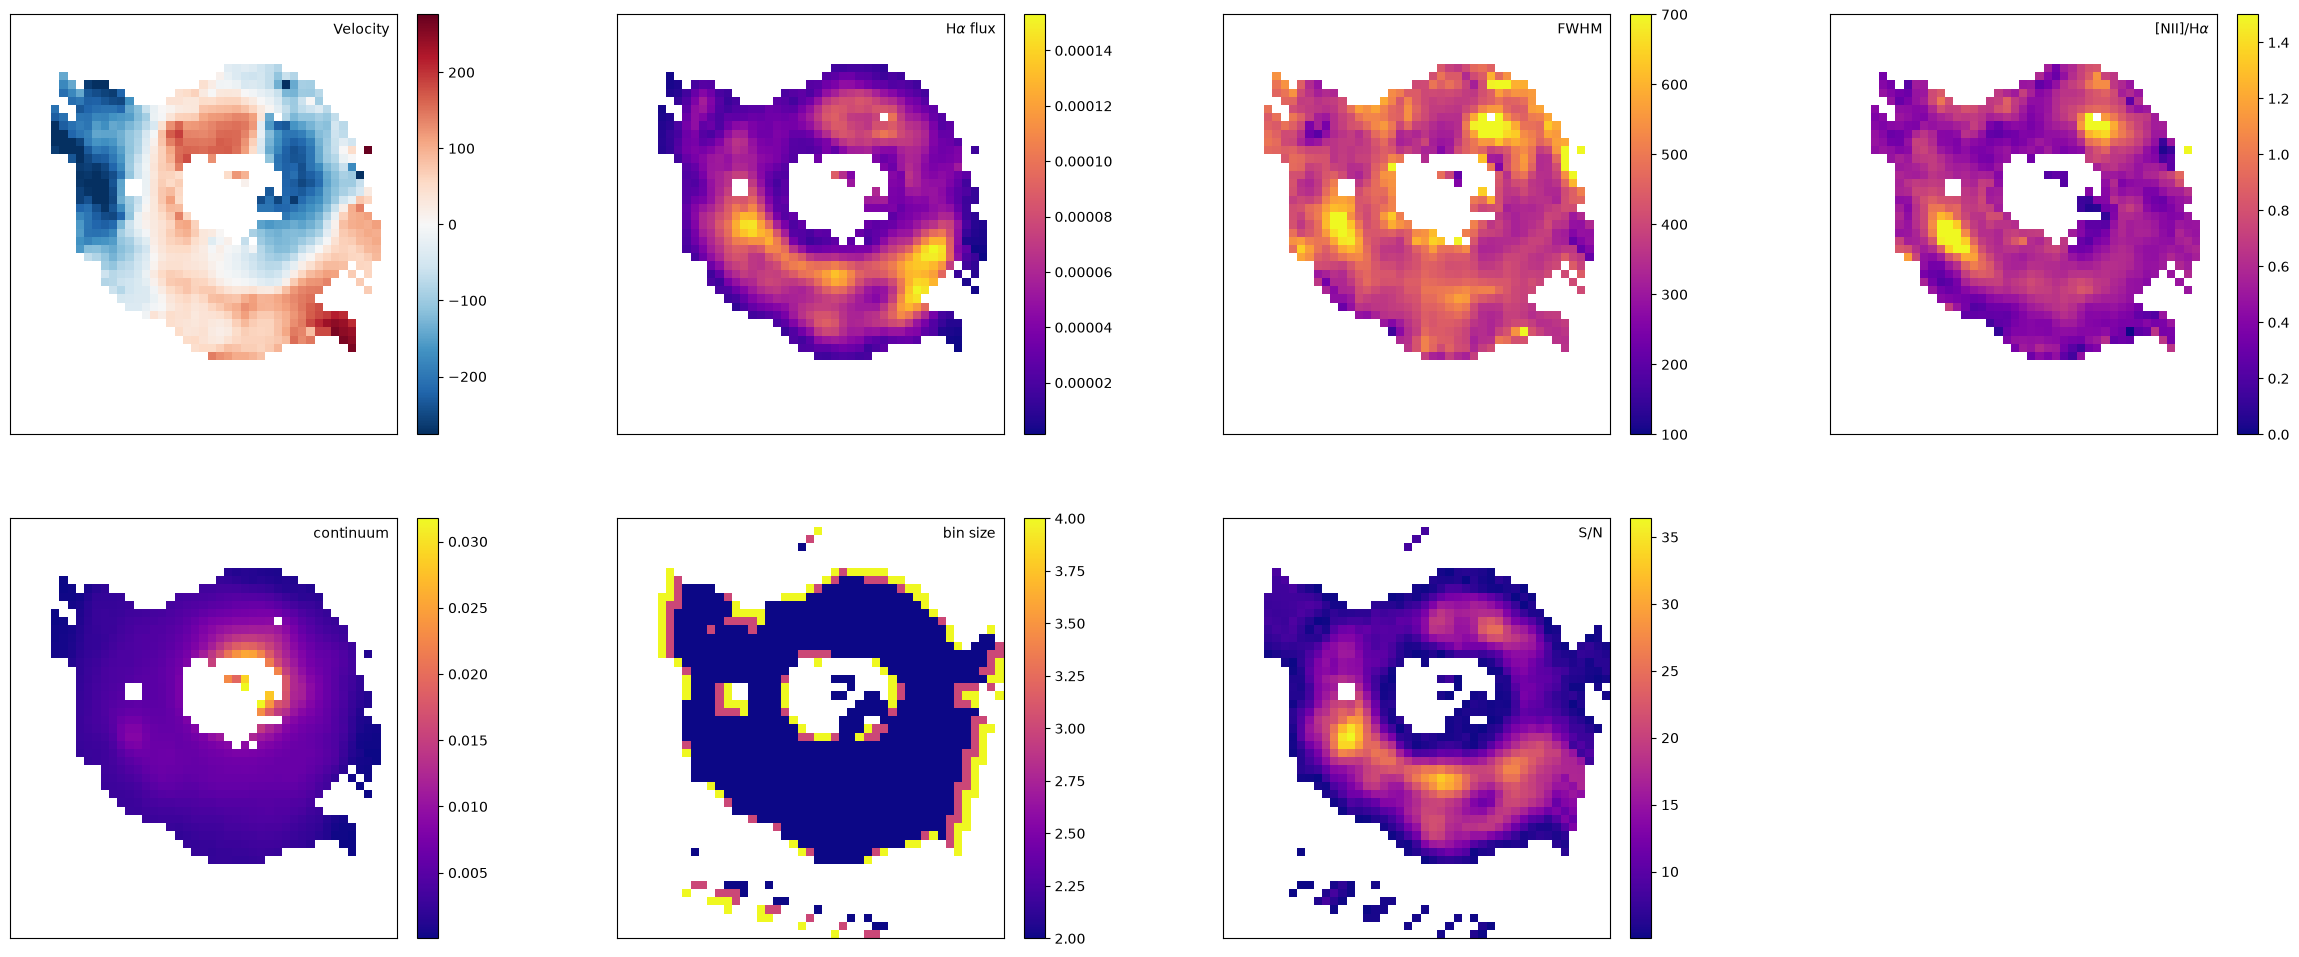

In [7]:
# Mask pixels whose parameters are pinned against a bound: they are artefacts of the
# prior rather than measurements, and they stretch the colour scales.
clean = (railed_map == 0)
pc = np.where(clean, param_cube, np.nan)

# Clip the velocity colour scale to the 2-98th percentile: a handful of extreme
# pixels otherwise stretch the scale and flatten the rotation signal.
vlo, vhi = np.nanpercentile(pc[0], [2, 98])
vmax = max(abs(vlo), abs(vhi))

fig = plt.figure(figsize=(30,12))
gs = gridspec.GridSpec(2,4)

# velocity map
ax0 = plt.subplot(gs[0])
im = ax0.imshow(pc[0], cmap="RdBu_r", vmin=-vmax, vmax=vmax)
plt.colorbar(im, fraction=0.046, pad=0.04)
# H-alpha integrated flux map
ax1 = plt.subplot(gs[1])
im = ax1.imshow(pc[1]*norm_map, cmap="plasma")
plt.colorbar(im, fraction=0.046, pad=0.04)
# FWHM map
ax2 = plt.subplot(gs[2])
im = ax2.imshow(pc[2]*2.35, cmap="plasma", vmin=100, vmax=700)
plt.colorbar(im, fraction=0.046, pad=0.04)
# [NII]/H-alpha map
ax3 = plt.subplot(gs[3])
im = ax3.imshow(pc[3], cmap="plasma", vmin=0, vmax=1.5)
plt.colorbar(im, fraction=0.046, pad=0.04)
# continuum map
ax4 = plt.subplot(gs[4])
im = ax4.imshow(pc[4]*norm_map, cmap="plasma")
plt.colorbar(im, fraction=0.046, pad=0.04)
# bin size map
ax5 = plt.subplot(gs[5])
im = ax5.imshow(bin_map, cmap="plasma")
plt.colorbar(im, fraction=0.046, pad=0.04)
# S/N map
ax6 = plt.subplot(gs[6])
im = ax6.imshow(snr_map, cmap="plasma")
plt.colorbar(im, fraction=0.046, pad=0.04)

labels = ["Velocity", r"H$\alpha$ flux", "FWHM", r"[NII]/H$\alpha$",
          "continuum", "bin size", "S/N"]
for i, ax in enumerate([ax0,ax1,ax2,ax3,ax4,ax5,ax6]):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.98, 0.98, labels[i], ha="right", va="top", transform=ax.transAxes, c="k")

plt.show()
